In [7]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from collections import Counter
from wordcloud import WordCloud

In [8]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
df = pd.read_csv("/content/amazon_review.csv")

print("Product Feedback Dataset")

print(df.head())

print("\nColumn Names")

print(df.columns)

Product Feedback Dataset
       reviewerID        asin  reviewerName helpful  \
0  A3SBTW3WS4IQSN  B007WTAJTO           NaN  [0, 0]   
1  A18K1ODH1I2MVB  B007WTAJTO          0mie  [0, 0]   
2  A2FII3I2MBMUIA  B007WTAJTO           1K3  [0, 0]   
3   A3H99DFEG68SR  B007WTAJTO           1m2  [0, 0]   
4  A375ZM4U047O79  B007WTAJTO  2&amp;1/2Men  [0, 0]   

                                          reviewText  overall  \
0                                         No issues.      4.0   
1  Purchased this for my device, it worked as adv...      5.0   
2  it works as expected. I should have sprung for...      4.0   
3  This think has worked out great.Had a diff. br...      5.0   
4  Bought it with Retail Packaging, arrived legit...      5.0   

                                  summary  unixReviewTime  reviewTime  \
0                              Four Stars      1406073600  2014-07-23   
1                           MOAR SPACE!!!      1382659200  2013-10-25   
2               nothing to really 

In [11]:
df = df[["reviewText", "overall"]]

df = df.dropna()

df = df.rename(columns={"reviewText": "Feedback"})

def create_sentiment(rating):

    if rating >= 4:

        return "Positive"

    elif rating <= 2:

        return "Negative"

    else:

        return "Neutral"

df["Sentiment"] = df["overall"].apply(create_sentiment)

print(df.head())

print("\nSentiment Distribution")

print(df["Sentiment"].value_counts())

                                            Feedback  overall Sentiment
0                                         No issues.      4.0  Positive
1  Purchased this for my device, it worked as adv...      5.0  Positive
2  it works as expected. I should have sprung for...      4.0  Positive
3  This think has worked out great.Had a diff. br...      5.0  Positive
4  Bought it with Retail Packaging, arrived legit...      5.0  Positive

Sentiment Distribution
Sentiment
Positive    4448
Negative     324
Neutral      142
Name: count, dtype: int64


In [12]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Feedback"] = df["Feedback"].apply(clean_text)

print(df[["Feedback", "Cleaned_Feedback"]].head())

                                            Feedback  \
0                                         No issues.   
1  Purchased this for my device, it worked as adv...   
2  it works as expected. I should have sprung for...   
3  This think has worked out great.Had a diff. br...   
4  Bought it with Retail Packaging, arrived legit...   

                                    Cleaned_Feedback  
0                                             issues  
1  purchased device worked advertised never much ...  
2  works expected sprung higher capacity think ma...  
3  think worked greathad diff bran gb card went s...  
4  bought retail packaging arrived legit orange e...  


In [13]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Feedback"])

y = df["Sentiment"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [15]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [16]:
y_pred = model.predict(X_test)

print("Predicted Sentiments")

print(y_pred)

Predicted Sentiments
['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positi

In [17]:
feedback = [

    "The product quality is excellent and very easy to use.",

    "The packaging was damaged and the product feels cheap.",

    "The product is okay but the price is a little high.",

    "Excellent quality and worth the money.",

    "Very difficult to use and poor build quality."

]

clean_feedback = []

for text in feedback:

    clean_feedback.append(clean_text(text))

feedback_vector = vectorizer.transform(clean_feedback)

prediction = model.predict(feedback_vector)

for text, sentiment in zip(feedback, prediction):

    print(text)

    print("Sentiment :", sentiment)

    print()

The product quality is excellent and very easy to use.
Sentiment : Positive

The packaging was damaged and the product feels cheap.
Sentiment : Positive

The product is okay but the price is a little high.
Sentiment : Positive

Excellent quality and worth the money.
Sentiment : Positive

Very difficult to use and poor build quality.
Sentiment : Positive



In [18]:
issues = []

keywords = [

    "quality",

    "price",

    "packaging",

    "expensive",

    "damaged",

    "difficult",

    "battery",

    "design",

    "delivery",

    "durability"

]

negative_reviews = df[df["Sentiment"] == "Negative"]

for review in negative_reviews["Cleaned_Feedback"]:

    for word in keywords:

        if word in review:

            issues.append(word)

issue_count = Counter(issues)

print("Product Improvement Areas")

print(issue_count.most_common(10))

Product Improvement Areas
[('price', 23), ('quality', 21), ('packaging', 15), ('expensive', 10), ('damaged', 6), ('battery', 5), ('design', 3), ('delivery', 1), ('difficult', 1), ('durability', 1)]


In [19]:
all_words = " ".join(df["Cleaned_Feedback"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("Top 10 Common Words")

print(word_freq.most_common(10))

Top 10 Common Words
[('card', 4603), ('gb', 1725), ('phone', 1685), ('works', 1559), ('great', 1445), ('memory', 1361), ('sandisk', 1286), ('sd', 1199), ('use', 1115), ('one', 1072)]


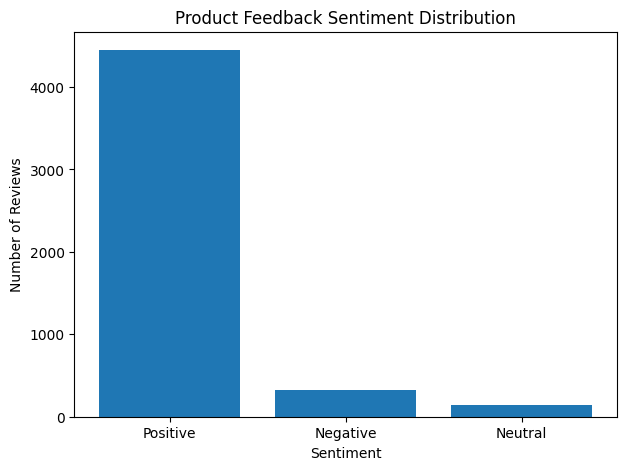

In [20]:
sentiment_count = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Product Feedback Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

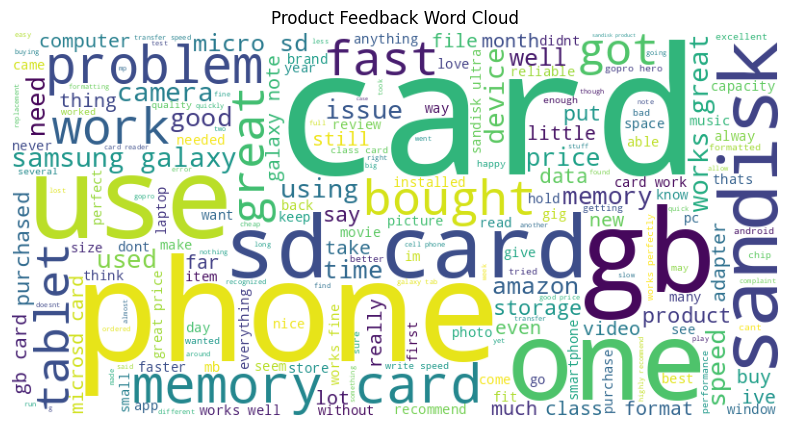

In [21]:
wordcloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Product Feedback Word Cloud")

plt.show()

In [22]:
positive = len(df[df["Sentiment"] == "Positive"])

negative = len(df[df["Sentiment"] == "Negative"])

neutral = len(df[df["Sentiment"] == "Neutral"])

print("Product Feedback Analysis Report")

print("-----------------------------------")

print("Positive Feedback :", positive)

print("Negative Feedback :", negative)

print("Neutral Feedback :", neutral)

print("\nProduct Improvement Areas")

print(issue_count.most_common(10))

print("\nTop Keywords")

print(word_freq.most_common(10))

print("\nBusiness Insights")

print("The company should focus on the most frequently reported issues in negative customer feedback, including product quality, pricing, packaging, usability, and durability. Addressing these areas can improve customer satisfaction and overall product performance.")

Product Feedback Analysis Report
-----------------------------------
Positive Feedback : 4448
Negative Feedback : 324
Neutral Feedback : 142

Product Improvement Areas
[('price', 23), ('quality', 21), ('packaging', 15), ('expensive', 10), ('damaged', 6), ('battery', 5), ('design', 3), ('delivery', 1), ('difficult', 1), ('durability', 1)]

Top Keywords
[('card', 4603), ('gb', 1725), ('phone', 1685), ('works', 1559), ('great', 1445), ('memory', 1361), ('sandisk', 1286), ('sd', 1199), ('use', 1115), ('one', 1072)]

Business Insights
The company should focus on the most frequently reported issues in negative customer feedback, including product quality, pricing, packaging, usability, and durability. Addressing these areas can improve customer satisfaction and overall product performance.
